# Fund Performance Analytics

## Mutual Fund Analytics Capstone

### Objectives

- Compute Daily Returns
- Compute CAGR (1 Year, 3 Year, 5 Year)
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Compute Alpha & Beta
- Compute Maximum Drawdown
- Create Fund Scorecard
- Compare Funds with Benchmark

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load datasets

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# Convert date columns

nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Date conversion completed!")

Date conversion completed!


In [4]:
# Sort NAV history

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Calculate Daily Returns

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [5]:
# First and Last NAV for each fund

cagr_data = (
    nav_history
    .groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last"),
        start_date=("date", "first"),
        end_date=("date", "last")
    )
)

cagr_data.head()

,start_nav,end_nav,start_date,end_date
amfi_code,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29
100025,26.3169,31.8843,2022-01-03,2026-05-29
100033,107.3758,342.0072,2022-01-03,2026-05-29
101206,305.0996,773.2939,2022-01-03,2026-05-29
101207,38.5736,53.9836,2022-01-03,2026-05-29


In [6]:
# Number of years

cagr_data["years"] = (
    (cagr_data["end_date"] - cagr_data["start_date"]).dt.days
    / 365.25
)

cagr_data.head()

,start_nav,end_nav,start_date,end_date,years
amfi_code,,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726
100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726
101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726
101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726


In [7]:
# CAGR Calculation

cagr_data["cagr"] = (
    (cagr_data["end_nav"] / cagr_data["start_nav"])
    ** (1 / cagr_data["years"])
    - 1
)

cagr_data.head()

,start_nav,end_nav,start_date,end_date,years,cagr
amfi_code,,,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371
100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232
101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384
101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388


In [8]:
# CAGR in %

cagr_data["cagr_pct"] = cagr_data["cagr"] * 100

cagr_data.head()

,start_nav,end_nav,start_date,end_date,years,cagr,cagr_pct
amfi_code,,,,,,,
100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371,2.637074
100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582,4.458210
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153
101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384,23.538361
101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388,7.938765


In [9]:
top_cagr = (
    cagr_data
    .sort_values("cagr_pct", ascending=False)
    .head(10)
)

top_cagr

,start_nav,end_nav,start_date,end_date,years,cagr,cagr_pct
amfi_code,,,,,,,
120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,0.328274,32.827406
119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,0.324235,32.423536
149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,0.322874,32.287440
148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,0.319495,31.949523
148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,0.309741,30.974108
120843,49.9131,163.2397,2022-01-03,2026-05-29,4.399726,0.309075,30.907455
100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153
149323,78.4622,245.3651,2022-01-03,2026-05-29,4.399726,0.295811,29.581087
119094,68.3023,203.8581,2022-01-03,2026-05-29,4.399726,0.282144,28.214417


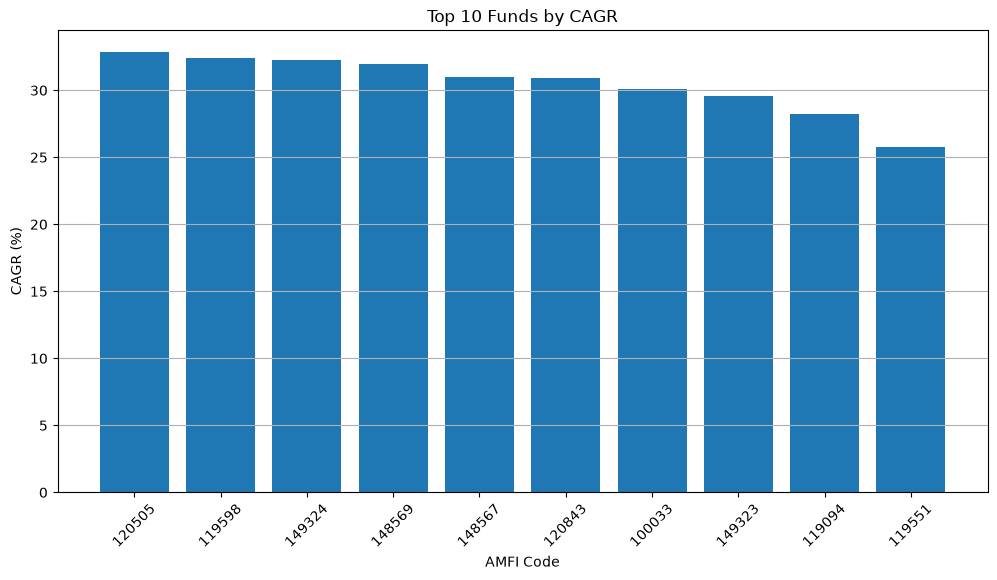

In [10]:
plt.figure(figsize=(12,6))

plt.bar(
    top_cagr.index.astype(str),
    top_cagr["cagr_pct"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.grid(axis="y")

plt.show()

In [11]:
# Risk-free rate (6.5% annually)

risk_free_rate = 0.065 / 252

In [12]:
# Sharpe Ratio for each fund

sharpe_data = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
)

sharpe_data["sharpe_ratio"] = (
    (sharpe_data["mean"] - risk_free_rate)
    / sharpe_data["std"]
) * np.sqrt(252)

sharpe_data.head()

,mean,std,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [13]:
top_sharpe = (
    sharpe_data
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

top_sharpe

,mean,std,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101
149323,0.001055,0.011179,1.132122
100033,0.001080,0.011929,1.093699
118632,0.000865,0.008913,1.081659
101206,0.000852,0.009177,1.027213


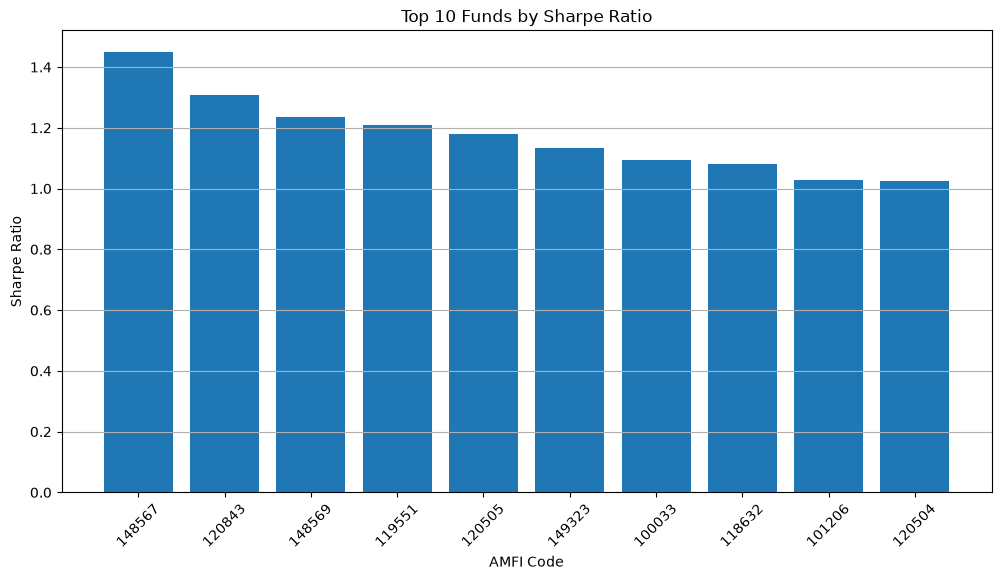

In [14]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sharpe.index.astype(str),
    top_sharpe["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [15]:
# Function to calculate Sortino Ratio

def calculate_sortino(group):
    downside_returns = group[group < 0]

    if len(downside_returns) == 0:
        return np.nan

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    average_return = group.mean()

    sortino = (
        (average_return - risk_free_rate)
        / downside_std
    ) * np.sqrt(252)

    return sortino

In [16]:
sortino_data = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .apply(calculate_sortino)
    .reset_index(name="sortino_ratio")
)

sortino_data.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [17]:
top_sortino = (
    sortino_data
    .sort_values("sortino_ratio", ascending=False)
    .head(10)
)

top_sortino

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


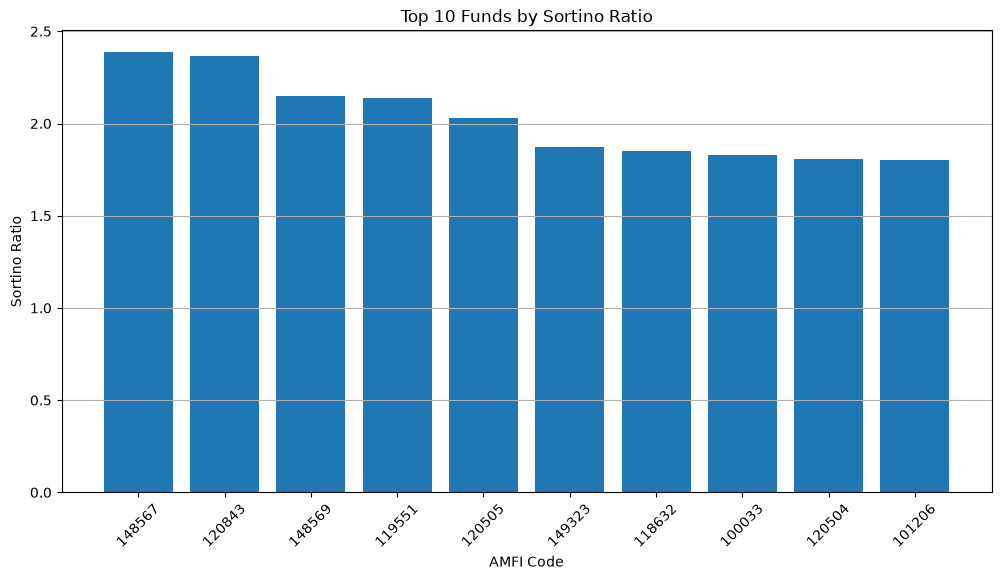

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sortino["amfi_code"].astype(str),
    top_sortino["sortino_ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [19]:
print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [20]:
# Sort benchmark data

benchmark = benchmark.sort_values("date")

# Calculate benchmark daily return

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [21]:
# Merge fund returns with benchmark returns

merged = pd.merge(
    nav_history,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,-0.869574
2,100016,2022-01-03,520.4608,NaN,3.261121
3,100016,2022-01-03,520.4608,NaN,-0.850741
4,100016,2022-01-03,520.4608,NaN,11.251899


In [22]:
alpha_beta = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund].dropna()

    if len(temp) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund,
        "alpha": alpha * 252,
        "beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [23]:
top_alpha = alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

top_alpha

,amfi_code,alpha,beta
39,149324,0.296003,0.000008
36,148569,0.295861,-0.000022
21,119598,0.295143,0.000013
34,148567,0.278900,-0.000014
25,120505,0.278249,0.000025
2,100033,0.265138,0.000012
30,120843,0.260693,0.000020
38,149323,0.260204,0.000010
16,119094,0.254863,0.000007
19,119551,0.222142,0.000015


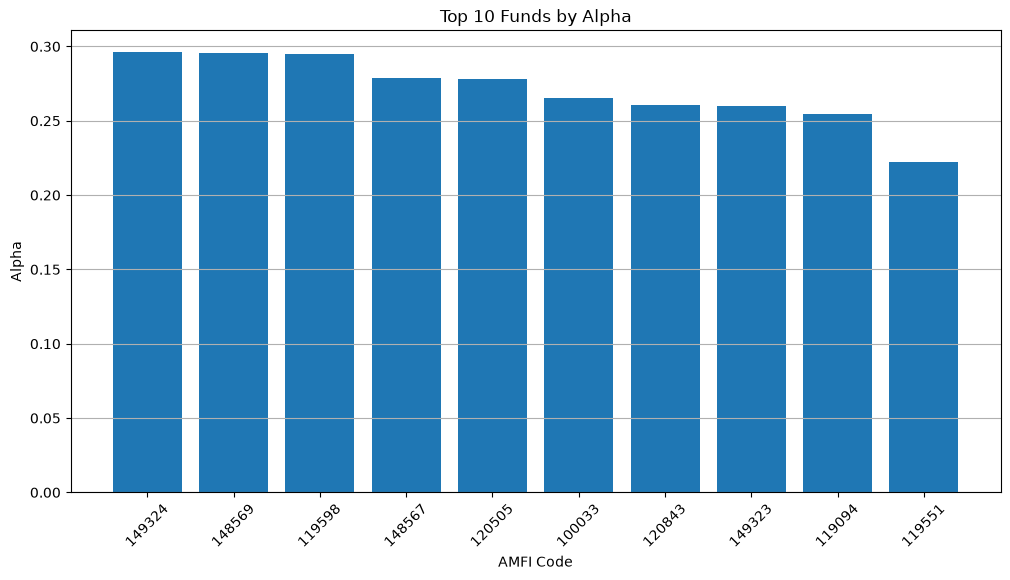

In [24]:
plt.figure(figsize=(12,6))

plt.bar(
    top_alpha["amfi_code"].astype(str),
    top_alpha["alpha"]
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [25]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [26]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [27]:
# Running Maximum NAV for each fund

nav_history["running_max"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .cummax()
)

nav_history.head()

,amfi_code,date,nav,daily_return,running_max
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


In [28]:
# Drawdown

nav_history["drawdown"] = (
    nav_history["nav"] / nav_history["running_max"]
) - 1

nav_history.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [29]:
# Maximum Drawdown

max_drawdown = (
    nav_history
    .groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.rename(
    columns={"drawdown": "max_drawdown"},
    inplace=True
)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [30]:
top_drawdown = (
    max_drawdown
    .sort_values("max_drawdown", ascending=False)
    .head(10)
)

top_drawdown

,amfi_code,max_drawdown
27,120507,-0.000977
31,120844,-0.001163
5,101208,-0.001622
1,100025,-0.043083
18,119120,-0.043287
13,118636,-0.083164
6,102885,-0.108599
34,148567,-0.112657
3,101206,-0.112916
12,118635,-0.116506


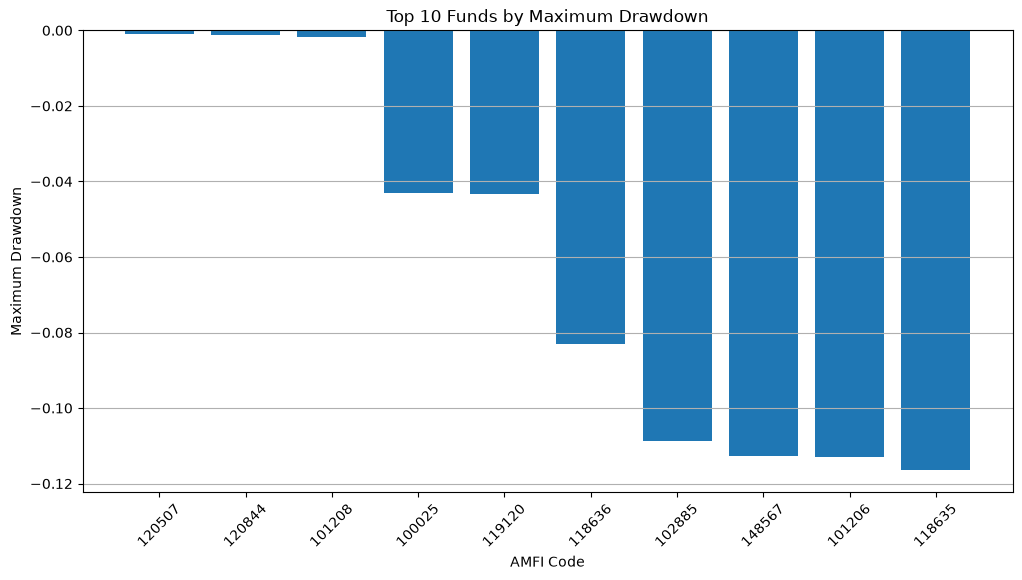

In [31]:
plt.figure(figsize=(12,6))

plt.bar(
    top_drawdown["amfi_code"].astype(str),
    top_drawdown["max_drawdown"]
)

plt.title("Top 10 Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [32]:
max_drawdown.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully!")

max_drawdown.csv saved successfully!


In [33]:
# Prepare all metrics

scorecard = pd.DataFrame({
    "amfi_code": cagr_data.index,
    "cagr": cagr_data["cagr_pct"].values
})

scorecard = scorecard.merge(
    sharpe_data["sharpe_ratio"].reset_index(),
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code"
)

# Expense ratio from performance dataset
scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,2.637074,-0.201517,0.037661,-0.247344,1.55
1,100025,4.458210,-0.567095,0.044818,-0.043083,0.56
2,100033,30.123153,1.093699,0.265138,-0.162172,1.38
3,101206,23.538361,1.027213,0.208464,-0.112916,1.60
4,101207,7.938765,0.162661,0.109861,-0.354469,1.53


In [34]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

# Lower expense ratio is better
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown is better
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,100016,2.637074,-0.201517,0.037661,-0.247344,1.55,37.0,35.0,39.0,32.0,34.0
1,100025,4.458210,-0.567095,0.044818,-0.043083,0.56,36.0,39.0,38.0,2.0,4.0
2,100033,30.123153,1.093699,0.265138,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0
3,101206,23.538361,1.027213,0.208464,-0.112916,1.60,12.0,9.0,13.0,36.5,9.0
4,101207,7.938765,0.162661,0.109861,-0.354469,1.53,27.0,28.0,27.0,28.5,38.0


In [35]:
scorecard["fund_score"] = (
    scorecard["cagr_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

In [36]:
max_rank = scorecard["fund_score"].max()
min_rank = scorecard["fund_score"].min()

scorecard["fund_score"] = (
    (max_rank - scorecard["fund_score"])
    / (max_rank - min_rank)
) * 100

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,2.637074,-0.201517,0.037661,-0.247344,1.55,37.0,35.0,39.0,32.0,34.0,1.106383
1,100025,4.458210,-0.567095,0.044818,-0.043083,0.56,36.0,39.0,38.0,2.0,4.0,24.936170
2,100033,30.123153,1.093699,0.265138,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,90.468085
3,101206,23.538361,1.027213,0.208464,-0.112916,1.60,12.0,9.0,13.0,36.5,9.0,72.680851
4,101207,7.938765,0.162661,0.109861,-0.354469,1.53,27.0,28.0,27.0,28.5,38.0,25.872340


In [37]:
top_scorecard = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(10)
)

top_scorecard

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
34,148567,30.974108,1.448291,0.278900,-0.112657,1.46,5.0,1.0,4.0,23.0,8.0,100.000000
25,120505,32.827406,1.180101,0.278249,-0.181885,1.36,1.0,5.0,5.0,15.0,25.0,98.297872
30,120843,30.907455,1.306744,0.260693,-0.129740,1.45,6.0,2.0,7.0,22.0,13.0,94.893617
2,100033,30.123153,1.093699,0.265138,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,90.468085
36,148569,31.949523,1.234930,0.295861,-0.163967,1.60,4.0,3.0,2.0,36.5,21.0,89.361702
21,119598,32.423536,0.945308,0.295143,-0.287060,1.43,2.0,14.0,3.0,21.0,36.0,84.170213
39,149324,32.287440,0.949796,0.296003,-0.311719,1.52,3.0,13.0,1.0,26.5,37.0,82.212766
24,120504,23.295119,1.026524,0.202935,-0.125883,0.80,13.0,10.0,14.0,12.0,12.0,81.617021
20,119552,21.524236,0.953279,0.191841,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,81.617021
19,119551,25.804686,1.208267,0.222142,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,81.361702


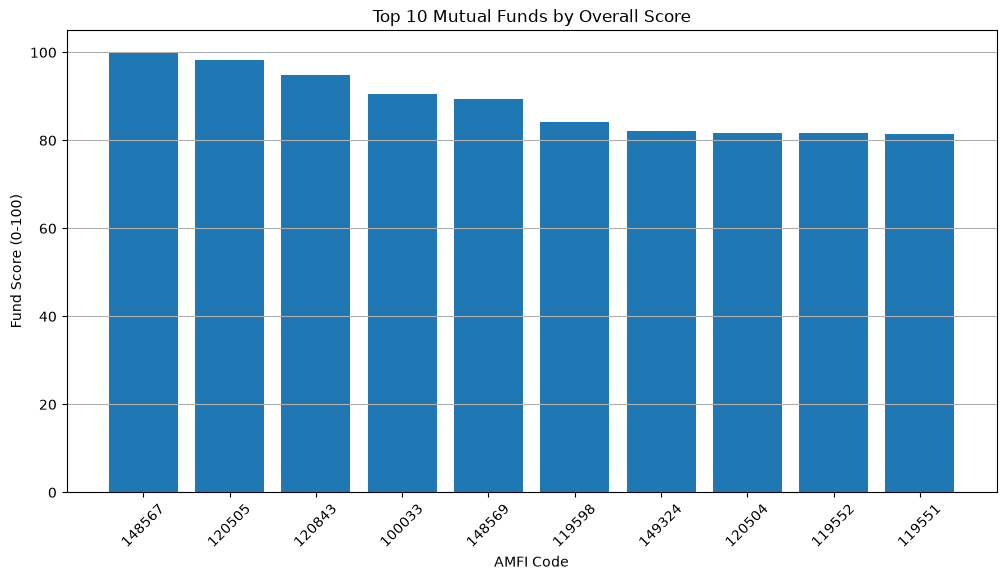

In [38]:
plt.figure(figsize=(12,6))

plt.bar(
    top_scorecard["amfi_code"].astype(str),
    top_scorecard["fund_score"]
)

plt.title("Top 10 Mutual Funds by Overall Score")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score (0-100)")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [40]:
# Top 5 funds based on fund score

top5_funds = top_scorecard["amfi_code"].head(5).tolist()

print(top5_funds)

[148567, 120505, 120843, 100033, 148569]


In [41]:
# Filter NAV data

top5_nav = nav_history[
    nav_history["amfi_code"].isin(top5_funds)
]

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
8050,100033,2022-01-03,107.3758,NaN,107.3758,0.000000
8051,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328
8052,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656
8053,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731
8054,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349


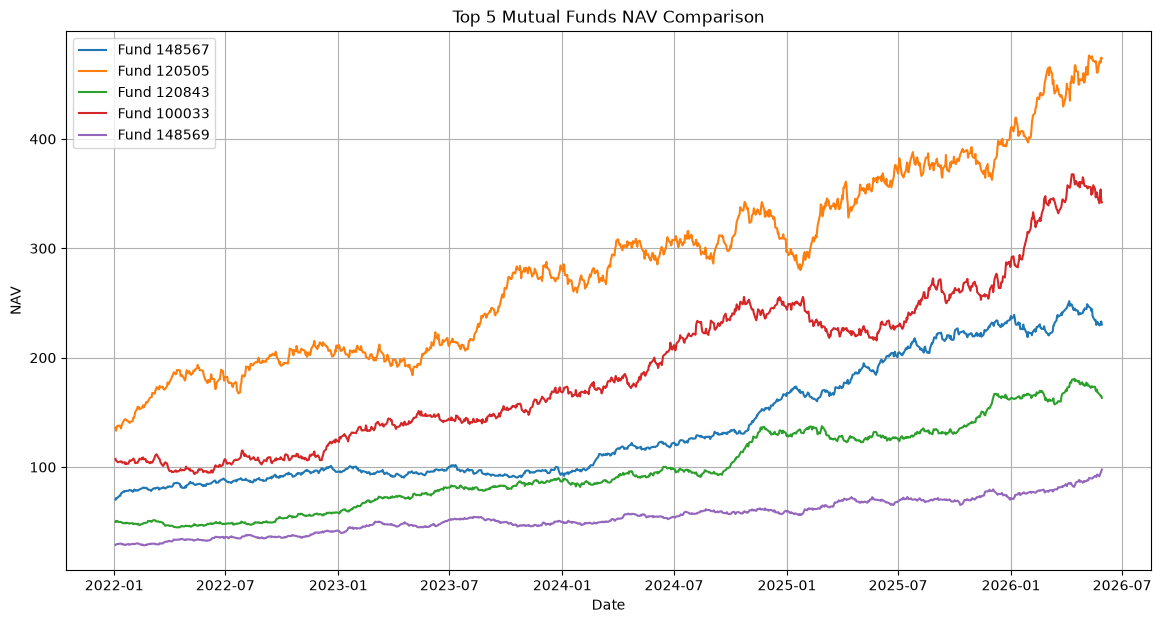

In [42]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {fund}"
    )

plt.title("Top 5 Mutual Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()
plt.grid(True)

plt.show()

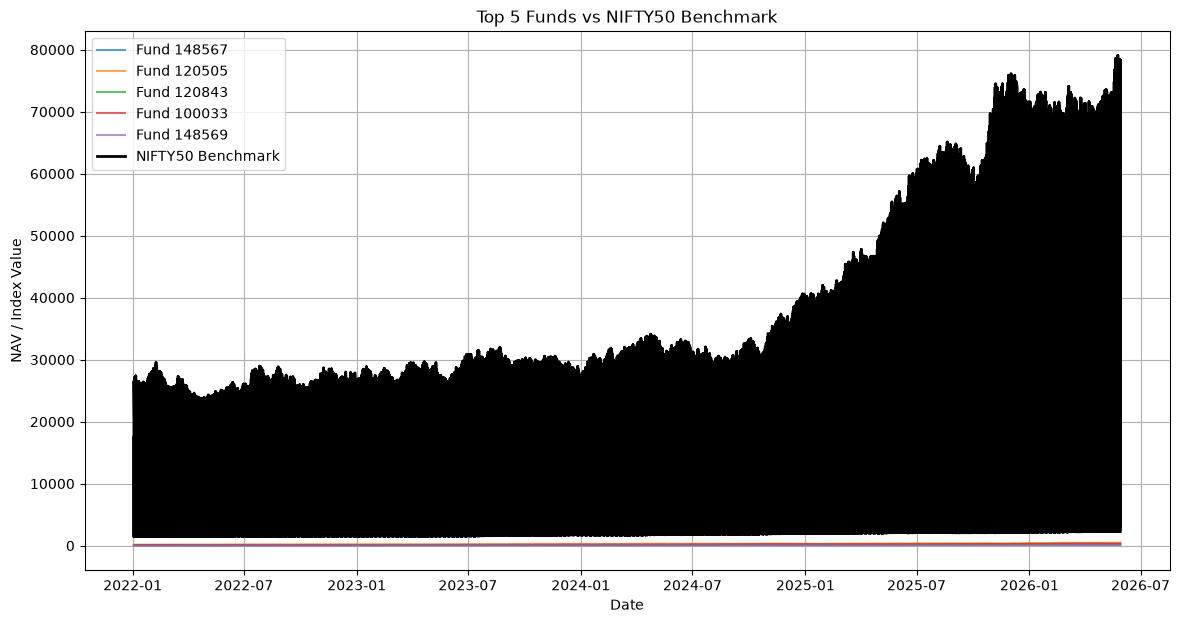

In [43]:
plt.figure(figsize=(14,7))

# Plot top 5 funds
for fund in top5_funds:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.7,
        label=f"Fund {fund}"
    )

# Plot benchmark
plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    color="black",
    linewidth=2,
    label="NIFTY50 Benchmark"
)

plt.title("Top 5 Funds vs NIFTY50 Benchmark")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()
plt.grid(True)

plt.show()

In [44]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Benchmark comparison chart saved!")

Benchmark comparison chart saved!


<Figure size 640x480 with 0 Axes>

In [39]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [ ]:
import os

print(os.getcwd())

In [ ]:
import os

print(os.getcwd())